In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as la
from matplotlib.collections import LineCollection

from tqdm import tqdm

from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala.lattice import cut_boundaries
from koala.graph_utils import make_dual, lloyd_relaxation, remove_trailing_edges
from koala import plotting as kplt
import matplotlib
from koala.lattice import Lattice

from matplotlib.colors import TwoSlopeNorm

matplotlib.rcParams.update({'font.size': 11, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern']})
from koala.example_graphs import square_lattice


In [6]:
def qwz_hamiltonian(lattice, u_vals, h_field = 0):
    if isinstance(u_vals, (int, float, complex)):
        u_vals = np.array([u_vals] * lattice.n_vertices)

    a_site_part = np.diag(u_vals+0j)
    b_site_part = -np.diag(u_vals+0j)

    ab_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)
    ba_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)

    p1 = lattice.vertices.positions[lattice.edges.indices[:, 0]]
    p2 = lattice.vertices.positions[lattice.edges.indices[:, 1]]   
    average_y = 0.5*(p1[:,1] + p2[:,1])
    change_x = p2[:,0] - p1[:,0]
    phases = -h_field * average_y * change_x * lattice.n_plaquettes

    for edge_index in range(lattice.n_edges):

        field_phase = 1j*phases[edge_index]*2*np.pi
        
        edge = lattice.edges.indices[edge_index]

        vec = lattice.edges.vectors[edge_index]
        angle = np.angle(vec[0] + 1j * vec[1])

        ab_link_part[edge[0], edge[1]] = 0.5j*np.exp(-1j*angle + field_phase)
        ba_link_part[edge[0], edge[1]] = 0.5j*np.exp(1j*angle + field_phase)
        a_site_part[edge[0], edge[1]] = 0.5*np.exp(field_phase)
        b_site_part[edge[0], edge[1]] = -0.5*np.exp(field_phase)

        # add conjugates
        ba_link_part[edge[1], edge[0]] = -0.5j*np.exp(1j*angle - field_phase)
        ab_link_part[edge[1], edge[0]] = -0.5j*np.exp(-1j*angle - field_phase)
        a_site_part[edge[1], edge[0]] = 0.5*np.exp(-field_phase)
        b_site_part[edge[1], edge[0]] = -0.5*np.exp(-field_phase)

    return np.block([
        [a_site_part, ab_link_part],
        [ba_link_part, b_site_part]
    ])

def step_marker(l, P):
    positions = l.vertices.positions 
    step_x = (positions[:,0]-0.5) > 0
    step_y = (positions[:,1]-0.5) > 0
    step_x = np.kron(np.ones(2), step_x)
    step_y = np.kron(np.ones(2), step_y)
    step_marker = (((P*step_x) @ (P*step_y) - (P*step_y) @ (P*step_y))@ P).diagonal().imag
    return step_marker[:l.n_vertices] + step_marker[l.n_vertices:]


def chern_marker(l, P, fix = False):
    positions = l.vertices.positions 
    x = positions[:,0]
    y = positions[:,1]
    x = np.kron(np.ones(2), x)
    y = np.kron(np.ones(2), y)

    shifts_x = np.outer(np.ones(l.n_vertices*2), x) - np.outer(x, np.ones(l.n_vertices*2))
    shifts_y = np.outer(np.ones(l.n_vertices*2), y) - np.outer(y, np.ones(l.n_vertices*2))

    if fix:
        shifts_x = (shifts_x + 0.5)%1 - 0.5
        shifts_y = (shifts_y + 0.5)%1 - 0.5

    marker = (P @ (P*shifts_x) @ (P*shifts_y) @ P).diagonal().imag
    m_out =  marker[:l.n_vertices] + marker[l.n_vertices:]
    return m_out*4*np.pi*l.n_vertices



In [38]:
lattice = square_lattice(50, 50)
lattice_small = square_lattice(20, 20)


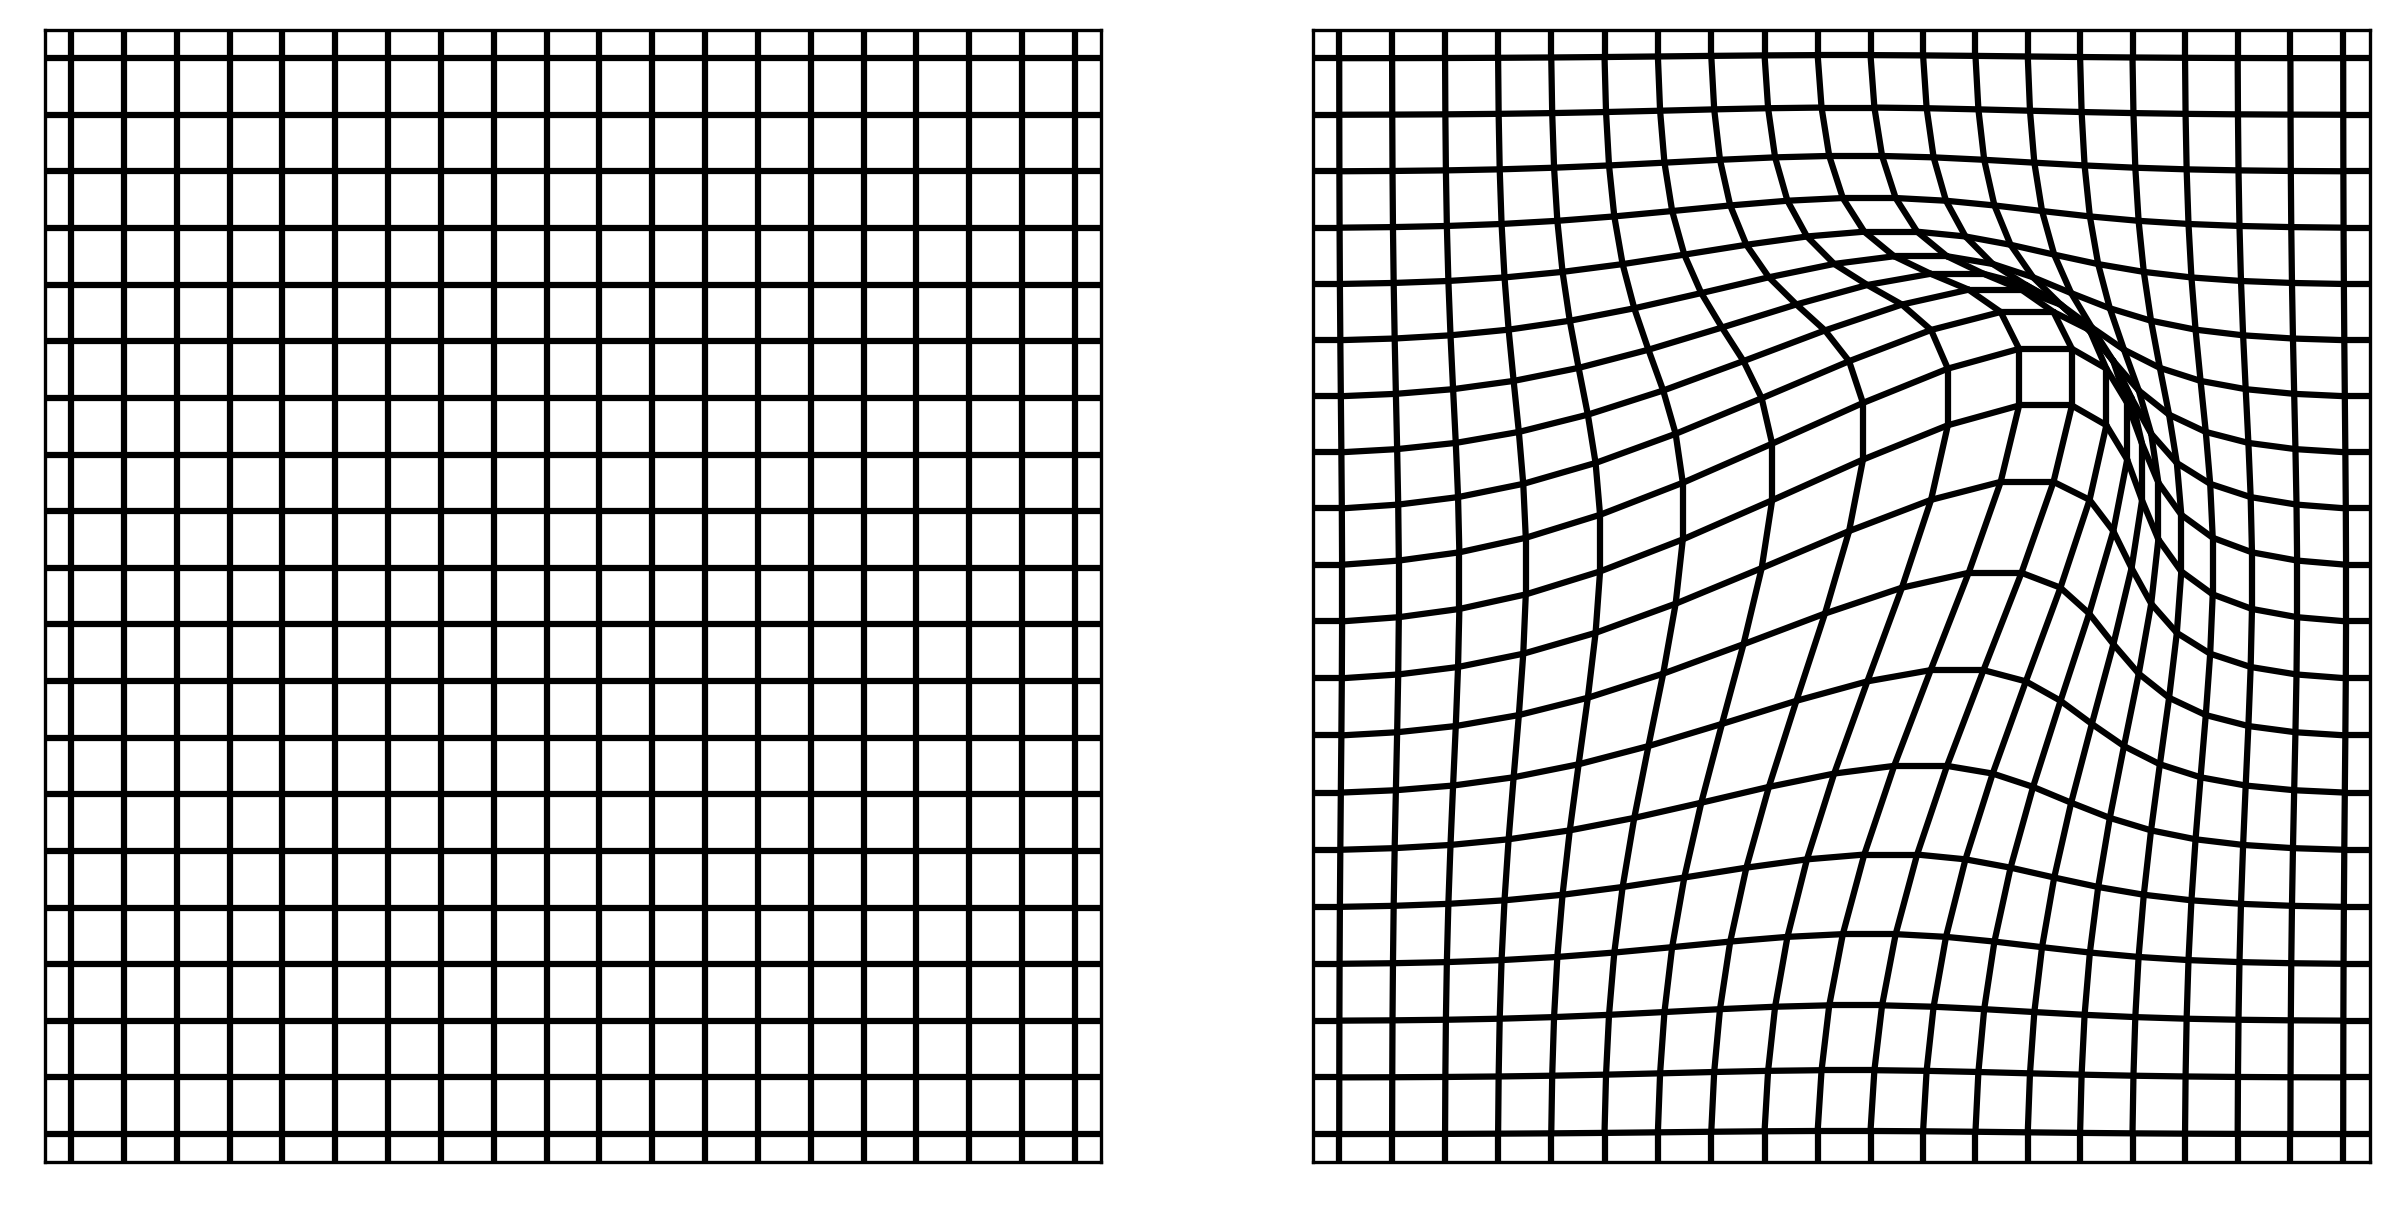

In [41]:

positions = lattice.vertices.positions
positions_small = lattice_small.vertices.positions
def point_shift(points):
    sigma = 0.23
    mag = 0.28
    r_from_center = np.linalg.norm(points-0.5, axis=1)
    gaussian = np.exp(-(r_from_center/sigma)**2)
    shift = mag * gaussian

    vector = np.array([1, 1])/np.sqrt(2)

    positions_out = points.copy()
    positions_out[:, 0] += shift*vector[0]
    positions_out[:, 1] += shift*vector[1]
    return positions_out


positions_shifted = point_shift(positions)
positions_shifted_small = point_shift(positions_small)


lattice2 = Lattice(positions_shifted, lattice.edges.indices, lattice.edges.crossing)
lattice2_small = Lattice(positions_shifted_small, lattice_small.edges.indices, lattice_small.edges.crossing)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi= 300)
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
kplt.plot_edges(lattice_small, ax=ax[0])
kplt.plot_edges(lattice2_small, ax=ax[1])

plt.savefig('chern_warp_lattices.pdf', bbox_inches='tight')


In [8]:
# h = qwz_hamiltonian(lattice, -0.5)
# e,v = la.eigh(h)
# p = v * (e<0) @ v.T.conj()
# chern = chern_marker(lattice, p, True)

In [34]:

chern_warped = chern_marker(lattice2, p, True)

-0.024248439262403988 2.0242481414220954


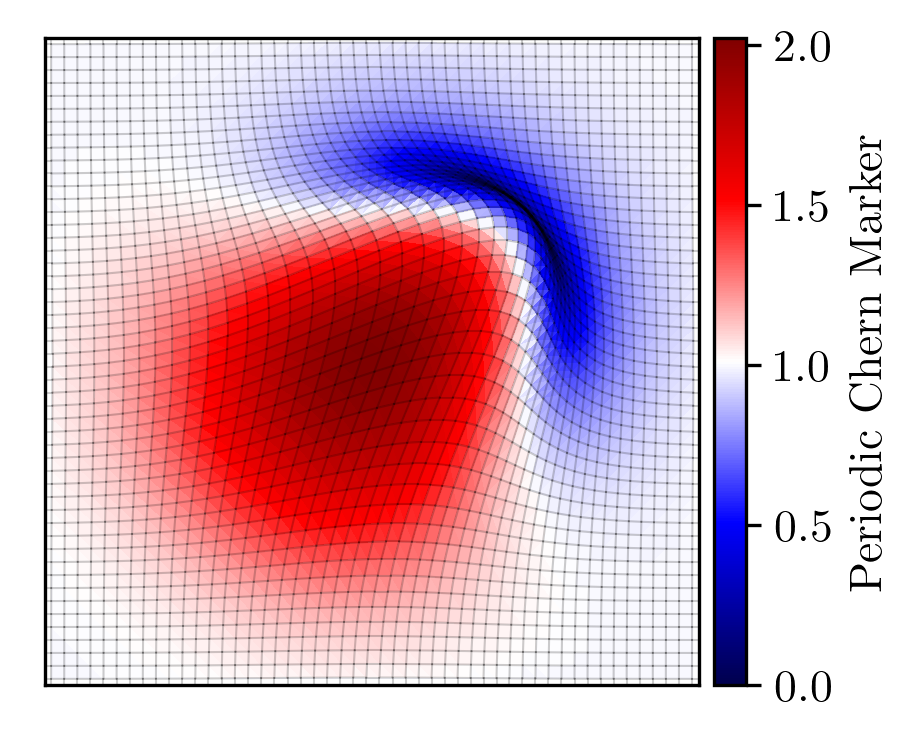

In [42]:
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1,1, figsize = (3.2,2.6), dpi = 300, tight_layout=True)

titles = '(b) OBC'
labels = 'Periodic Chern Marker'

ax.set_xticks([])
ax.set_yticks([])
kplt.plot_edges(lattice2, ax = ax, color = 'k', linewidth = 0.5, alpha = 0.2)

x_vals = lattice2.vertices.positions[:,0]
y_vals = lattice2.vertices.positions[:,1]

z_vals =  chern_warped
print(z_vals.min(), z_vals.max())
vcenter = np.average(z_vals)
divnorm = colors.TwoSlopeNorm(vmin=z_vals.min(), vcenter=vcenter, vmax=z_vals.max())
# pcm = ax[n].tripcolor(x_vals, y_vals, z_vals, norm= divnorm, cmap= 'seismic', rasterized=True) 
pcm = ax.tripcolor(x_vals, y_vals, z_vals, cmap= 'seismic', rasterized=True) 

# pcm = ax[n].tripcolor(x_vals, y_vals, z_vals, cmap= 'seismic', rasterized=True) 

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(pcm, cax=cax, orientation='vertical', label = labels)
# ax[n].set_title(titles[n])

plt.savefig('chern_warp.pdf', bbox_inches='tight')
